## 1 Construction d'un modele KNN

K-Nearest Neighbors (KNN) est un type d'apprentissage supervisé pour la classification  et la régression. KNN fonctionne en trouvant les 'K' échantillons les plus proches dans l'ensemble de données d'apprentissage d'un nouvel  échantillon non classé. L'échantillon non classé est ensuite classé basé sur la majorité des classes des 'K' échantillons les plus proches.

### 1.1 Etape 1: Choisir le nombre K de voisins
La premiere étape de l'utilsation de l'algorithme KNN est de choisir le nombre 'K' de voisins. Il s'agit du nombre de voisin que nous examinerons pour determiner la classification d'un point de données non classé.

### 1.2 Etape 2: Calculer les distances euclidiennes 
Apres avoir choisi un 'K', calculez la distance entre le point de données à classer et les autres points de données. La distance euclidienne est généralement utilisée pour cela, mais d'autres mesures de distance comme la distance de Manhattan peuvent aussi etre utilisées.

### 1.3 Etape 3: Trouver les K voisins les plus proches 
Trouver les 'K' points de données dans notre ensemble de données d'entrainement qui sont les plus proches du point de données que nous essayonsde classer.

### 1.4 Etape 4: Voter pour la classe majoritaire
Une fois que nous avons identifié les 'K' voisins les plus proches, nous les utilisons pour voter pour la classe du point de données non classé. Le point de données non classé est généralement attribué à la classe qui a le plus de voisins parmi les 'K' voisins les plus proches.

### 1.5 Etape 5: Classer le point de données non classé

En fonction du vote majoritaire des 'K' voisins, nous classons le point de données non classé.

Repetez les étapes 2 à 5 pour chaque point de données non classé dans l'ensemble de test.

Note: L'algorithme KNN est un algorithme "paresseux" ce qui signifie qu'il ne construit pas un modele utilisant l'ensemble d'apprentissage avant de faire des predictions. Il fait des calculs au moment de faire des preédictions. Il peut donc etre couteux en temps et en ressources pour les grands ensembles de données.

##  2 Importation des packages et chargement des données

In [1]:
import matplotlib.pyplot as plt 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV

In [10]:
# Chargement du jeu de donnés Iris 
iris = load_iris()
X = iris.data # caracteristiques
y = iris.target # etiquettes 

In [9]:
print(iris.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


## 3 KNN pour la classification


In [ ]:
# Division des données en ensemble d'entrainement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Liste des valeurs de k à tester
k_values = list(range(1, 20))


In [13]:
# Creation de l'instance du classificateur KNN
knn = KNeighborsClassifier()
# Parametres pour la recherche de grille
param_grid = {'n_neighbors':k_values}

# Recherche de grille avec validation croisée
grid_search = GridSearchCV(knn, param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Extraction des scores de validation croisée et des valeurs de k corresponantes 
cv_scores = grid_search.cv_results_['mean_test_score']
best_k = grid_search.best_params_['n_neighbors']

In [14]:
best_k

3

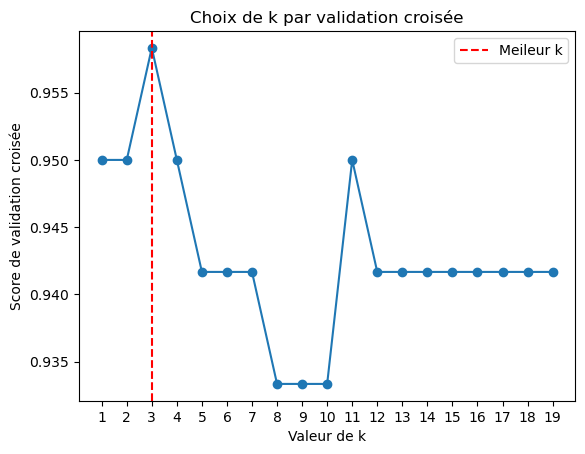

In [15]:
# Tracé du graphique des scores de validation croisée en fonction de k
plt.plot(k_values, cv_scores, '-o')
plt.xlabel('Valeur de k')
plt.ylabel('Score de validation croisée')
plt.title('Choix de k par validation croisée')
plt.xticks(k_values)
plt.axvline(x=best_k, color='r', linestyle='--', label='Meileur k')
plt.legend()
plt.show()

In [17]:
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score
best_model = grid_search.best_estimator_
# Prediction sur l'ensemble d'entrainement
y_train_pred = best_model.predict(X_train)
y_train_pred_proba = best_model.predict_proba(X_train)[:, 1]

# Prediction sur l'ensemble de test
y_test_pred = best_model.predict(X_test)
y_test_pred_proba = best_model.predict_proba(X_test)[:, 1]

# Calcul de l'execution sur les ensembles d'entrainement et de test
accuracy_train = accuracy_score(y_train, y_train_pred)
accuracy_test = accuracy_score(y_test, y_test_pred)
print("Exactitude sur l'ensemble d'entrainement : {:.2f}%".format(accuracy_train * 100))
print("Exactitude sur l'ensemble de test : {:.2f}%".format(accuracy_test * 100))

Exactitude sur l'ensemble d'entrainement : 95.00%
Exactitude sur l'ensemble de test : 100.00%


## 4 KNN pour la régression

In [42]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

In [31]:
# Charger le jeu de données California Housing
data = fetch_california_housing(as_frame=True)
X = data.data
y = data.target

In [32]:
# Diviser les données en ensembles d'entrainement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
# Creeation d'un modele KNN pour la regresion
knn = KNeighborsRegressor()
# Definir les hyperparametres à tester avec GridSearchCV
param_grid = {'n_neighbors': [3, 5, 6, 7, 9, 10, 11, 12]}

# Recherche des meilleurs hyperparametres avec GridSearchCV
grid_search = GridSearchCV(knn, param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Obtenir les meilleurs hyperparametres
best_k = grid_search.best_params_['n_neighbors']
best_k

9

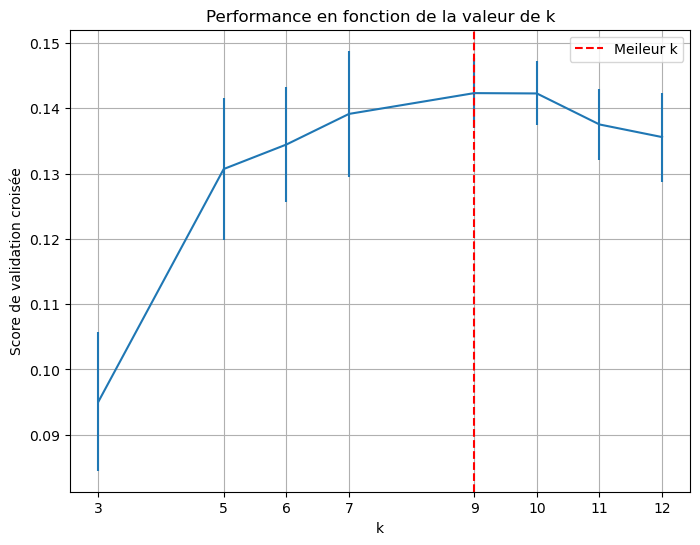

In [36]:
# Obtenir les scores de validation croisée pour chaque valeur de k
cv_results = grid_search.cv_results_
mean_test_scores = cv_results['mean_test_score']
std_test_scores = cv_results['std_test_score']

# Afficher les performances en fonction de k
plt.figure(figsize=(8, 6))
plt.errorbar(param_grid['n_neighbors'], mean_test_scores, yerr=std_test_scores)
plt.title('Performance en fonction de la valeur de k')
plt.xlabel('k')
plt.ylabel('Score de validation croisée')
plt.xticks(param_grid['n_neighbors'])
plt.axvline(best_k, color='r', linestyle='--', label='Meileur k')
plt.legend()
plt.grid(True)
plt.show()

In [44]:
import numpy as np

# Entrainer le modele avec les meilleurs hyperparametres 
knn_best = KNeighborsRegressor(n_neighbors=best_k)
knn_best.fit(X_train, y_train)

# Predire sur l'ensemble d'entrainement et de test
y_train_pred = knn_best.predict(X_train)
y_test_pred = knn_best.predict(X_test)

# Calculer les performances 
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

# Creer un tableau des performances 
performance_table = pd.DataFrame({
    'Performance' : ['RMSE', 'R2 Score'],
    'Train' : [train_rmse, train_r2],
    'Test' : [test_rmse, test_r2]
})

# Afficher le tableau des performances 
print(performance_table)

  Performance     Train      Test
0        RMSE  0.940455  1.050358
1    R2 Score  0.338367  0.158086
